# Test Audio Dataset - RAVDESS e IEMOCAP

Notebook per testare e ascoltare audio dai dataset RAVDESS e IEMOCAP.

**Funzionalità:**
- 🔊 Ascoltare campioni audio casuali
- 📊 Visualizzare statistiche del dataset
- 🎵 Visualizzare waveform e spettrogrammi
- 🔍 Valutare qualità degli audio e rilevare file corrotti

In [9]:
import sys
import os
from pathlib import Path
import random
import numpy as np
import librosa
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import pandas as pd
from collections import defaultdict

# Aggiungi i path necessari per importare i moduli (utils, dataset, etc.)
workspace_root = Path.cwd().parent  # Dal notebook in dataset/ al progetto root
sys.path.insert(0, str(workspace_root))
sys.path.insert(0, str(Path.cwd()))

# Disabilita avvertimenti di librosa
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print("✅ Librerie importate con successo")

✅ Librerie importate con successo


In [10]:
from custom_ravdess_dataset import CustomRAVDESSDataset
from custom_iemocap_dataset import CustomIEMOCAPDataset

# Definisci i path ai dataset
RAVDESS_ROOT = Path("../data/ravdess")
IEMOCAP_ROOT = Path("../data/iemocap/IEMOCAP_full_release")

print(f"📁 RAVDESS root: {RAVDESS_ROOT.resolve()}")
print(f"📁 IEMOCAP root: {IEMOCAP_ROOT.resolve()}")

# Verifica che i percorsi esistono
if not RAVDESS_ROOT.exists():
    print(f"⚠️  Path RAVDESS non trovato: {RAVDESS_ROOT}")
if not IEMOCAP_ROOT.exists():
    print(f"⚠️  Path IEMOCAP non trovato: {IEMOCAP_ROOT}")

📁 RAVDESS root: D:\Roba da D\Poli\ML Vision\speech-emotion-recognition-25\data\ravdess
📁 IEMOCAP root: D:\Roba da D\Poli\ML Vision\speech-emotion-recognition-25\data\iemocap\IEMOCAP_full_release


## 1️⃣ Caricamento Dataset RAVDESS e IEMOCAP

Carica i dataset con splitting per actor (RAVDESS) e session (IEMOCAP)

In [11]:
# Dizionario per conservare i dataset per accesso veloce
ravdess_datasets = {}
iemocap_datasets = {}

print("=" * 70)
print("🎵 CARICAMENTO RAVDESS DATASET")
print("=" * 70)

# Carica RAVDESS (train, validation, test)
for split in ['train', 'validation', 'test']:
    try:
        ravdess_datasets[split] = CustomRAVDESSDataset(
            dataset_root=str(RAVDESS_ROOT),
            split=split
        )
        print(f"✅ RAVDESS {split}: {len(ravdess_datasets[split])} campioni")
    except Exception as e:
        print(f"❌ Errore caricamento RAVDESS {split}: {e}")

print("\n" + "=" * 70)
print("🎙️  CARICAMENTO IEMOCAP DATASET")
print("=" * 70)

# Carica IEMOCAP (train, validation, test)
for split in ['train', 'validation', 'test']:
    try:
        iemocap_datasets[split] = CustomIEMOCAPDataset(
            dataset_root=str(IEMOCAP_ROOT),
            split=split
        )
        print(f"✅ IEMOCAP {split}: {len(iemocap_datasets[split])} campioni")
    except Exception as e:
        print(f"❌ Errore caricamento IEMOCAP {split}: {e}")

🎵 CARICAMENTO RAVDESS DATASET
📊 Statistiche del dataset RAVDESS:

📊 ANALISI RAVDESS TRAINING SET
🔹 Samples Totali: 1440
🔹 Attori (20): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
   - Maschi:  10
   - Femmine: 10

🎭 Distribuzione Emozioni:
   - Angry     :  320 ( 22.2%) ████
   - Happy     :  320 ( 22.2%) ████
   - Neutral   :  480 ( 33.3%) ██████
   - Sad       :  320 ( 22.2%) ████
----------------------------------------
✅ RAVDESS train: 1440 campioni
📊 Statistiche del dataset RAVDESS:

📊 ANALISI RAVDESS VALIDATION SET
🔹 Samples Totali: 144
🔹 Attori (2): [21, 22]
   - Maschi:  1
   - Femmine: 1

🎭 Distribuzione Emozioni:
   - Angry     :   32 ( 22.2%) ████
   - Happy     :   32 ( 22.2%) ████
   - Neutral   :   48 ( 33.3%) ██████
   - Sad       :   32 ( 22.2%) ████
----------------------------------------
✅ RAVDESS validation: 144 campioni
📊 Statistiche del dataset RAVDESS:

📊 ANALISI RAVDESS TEST SET
🔹 Samples Totali: 144
🔹 Attori (2): [23, 24]
   - Maschi

## 2️⃣ Statistiche Dataset

Visualizza la distribuzione di emozioni, speaker e altre proprietà

In [12]:
def print_dataset_summary(is_ravdess=True):
    """Stampa un riepilogo delle statistiche del dataset"""
    
    datasets = ravdess_datasets if is_ravdess else iemocap_datasets
    dataset_name = "RAVDESS" if is_ravdess else "IEMOCAP"
    
    print(f"\n{'='*70}")
    print(f"📊 STATISTICHE {dataset_name} DATASET")
    print(f"{'='*70}\n")
    
    for split, dataset in datasets.items():
        if dataset is None:
            continue
            
        print(f"\n🔹 {split.upper()} ({len(dataset)} campioni)")
        
        # Conteggi per emozione
        emotion_counts = defaultdict(int)
        actor_counts = defaultdict(int)
        
        for i in range(len(dataset)):
            sample = dataset.samples[i]
            
            if is_ravdess:
                emotion = sample['metadata']['emotion_label']
                actor = sample['metadata']['actor']
            else:
                emotion = sample['label']
                actor = sample['actor']
            
            emotion_counts[emotion] += 1
            actor_counts[actor] += 1
        
        # Visualizza conteggi emozioni
        print("   Emozioni:")
        for emotion in ['neutral', 'happy', 'sad', 'angry']:
            count = emotion_counts.get(emotion, 0)
            bar = "▓" * (count // 5) if count > 0 else ""
            print(f"      {emotion:10s}: {count:3d} {bar}")
        
        print(f"   Speaker: {len(actor_counts)} attori unici")

# Visualizza statistiche
print_dataset_summary(is_ravdess=True)
print_dataset_summary(is_ravdess=False)


📊 STATISTICHE RAVDESS DATASET


🔹 TRAIN (1440 campioni)
   Emozioni:
      neutral   : 480 ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
      happy     : 320 ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
      sad       : 320 ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
      angry     : 320 ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   Speaker: 20 attori unici

🔹 VALIDATION (144 campioni)
   Emozioni:
      neutral   :  48 ▓▓▓▓▓▓▓▓▓
      happy     :  32 ▓▓▓▓▓▓
      sad       :  32 ▓▓▓▓▓▓
      angry     :  32 ▓▓▓▓▓▓
   Speaker: 2 attori unici

🔹 TEST (144 campioni)
   Emozioni:
      neutral   :  48 ▓▓▓▓▓▓▓▓▓
      happy     :  32 ▓▓▓▓▓▓
      sad       :  32 ▓▓▓▓▓▓
      angry     :  32 ▓▓▓▓▓▓
   Speaker: 2 attori unici

📊 STATISTICHE IEMOCAP DATASET


🔹 TRAIN (1678 campioni)
   Emozioni:
      neutral   :   0 
      happy     :   0 
      sad       : 394 ▓▓▓▓▓▓▓▓▓▓▓▓▓▓

## 3️⃣ Selezione Casuale e Playback Audio

Seleziona e ascolta campioni audio casuali da ogni dataset

In [13]:
def play_random_sample(dataset, split='train', num_samples=1):
    """
    Seleziona e riproduce un campione audio casuale dal dataset
    """
    is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
    dataset_name = "RAVDESS" if is_ravdess else "IEMOCAP"
    data = dataset.samples
    
    print(f"\n🎵 PLAYBACK AUDIO CASUALE - {dataset_name} ({split})")
    print("=" * 70)
    
    for i in range(num_samples):
        # Seleziona indice casuale
        idx = random.randint(0, len(data) - 1)
        sample = data[idx]
        
        # Estrai metadata
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
            actor = sample['metadata']['actor']
            intensity = sample['metadata']['intensity']
            info = f"Attore: {actor} | Intensità: {'Normal' if intensity == '01' else 'Strong'}"
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
            actor = sample['actor']
            session = sample['session_id']
            info = f"Attore: {actor} | Session: {session}"
        
        # Carica audio
        try:
            waveform, sr = librosa.load(str(audio_path), sr=None)
            duration = len(waveform) / sr
            
            print(f"\n📂 Sample {i+1}/{num_samples}")
            print(f"   File: {audio_path.name}")
            print(f"   Emozione: {emotion:10s} | Durata: {duration:.2f}s | SR: {sr}Hz")
            print(f"   {info}")
            print(f"   Ampiezza: min={waveform.min():.4f} | max={waveform.max():.4f} | mean={waveform.mean():.4f}")
            
            # Riproduci audio
            display(Audio(data=waveform, rate=sr))
            
        except Exception as e:
            print(f"❌ Errore caricamento: {e}")

# Funzione wrapper per RAVDESS
def play_ravdess_sample(split='train', num_samples=1):
    if split not in ravdess_datasets or ravdess_datasets[split] is None:
        print(f"❌ Dataset RAVDESS {split} non disponibile")
        return
    play_random_sample(ravdess_datasets[split], split, num_samples)

# Funzione wrapper per IEMOCAP
def play_iemocap_sample(split='train', num_samples=1):
    if split not in iemocap_datasets or iemocap_datasets[split] is None:
        print(f"❌ Dataset IEMOCAP {split} non disponibile")
        return
    play_random_sample(iemocap_datasets[split], split, num_samples)

In [14]:
# Ascolta audio casuale da RAVDESS TRAINING
play_ravdess_sample(split='train', num_samples=2)


🎵 PLAYBACK AUDIO CASUALE - RAVDESS (train)

📂 Sample 1/2
   File: 03-01-03-02-01-01-20.wav
   Emozione: happy      | Durata: 3.67s | SR: 48000Hz
   Attore: 20 | Intensità: Strong
   Ampiezza: min=-0.2142 | max=0.2227 | mean=0.0000



📂 Sample 2/2
   File: 03-01-05-02-01-02-11.wav
   Emozione: angry      | Durata: 3.97s | SR: 48000Hz
   Attore: 11 | Intensità: Strong
   Ampiezza: min=-0.6722 | max=0.6536 | mean=0.0000


In [15]:
# Ascolta audio casuale da IEMOCAP TRAINING
play_iemocap_sample(split='train', num_samples=2)


🎵 PLAYBACK AUDIO CASUALE - IEMOCAP (train)

📂 Sample 1/2
   File: Ses02F_impro07_F011.wav
   Emozione: exc        | Durata: 8.12s | SR: 16000Hz
   Attore: F | Session: 2
   Ampiezza: min=-0.2441 | max=0.2958 | mean=-0.0000



📂 Sample 2/2
   File: Ses01M_impro04_F021.wav
   Emozione: neu        | Durata: 2.82s | SR: 16000Hz
   Attore: M | Session: 1
   Ampiezza: min=-0.1484 | max=0.1356 | mean=-0.0000


## 4️⃣ Visualizzazione Waveform

Visualizza il segnale audio grezzo nel dominio del tempo

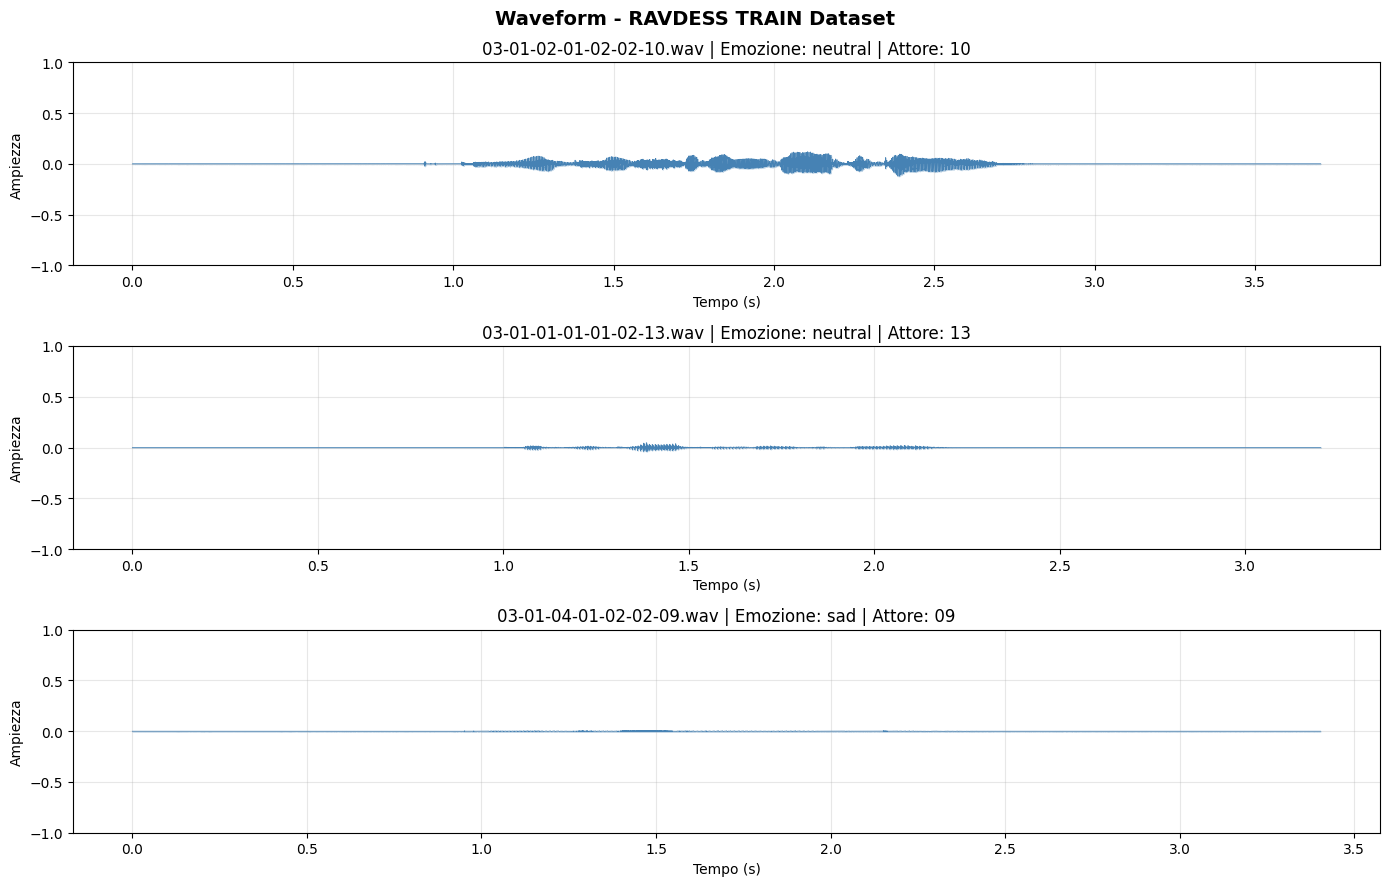

In [16]:
def plot_waveform(dataset, split='train', num_samples=3):
    """
    Visualizza waveform di campioni casuali
    """
    is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
    dataset_name = "RAVDESS" if is_ravdess else "IEMOCAP"
    data = dataset.samples
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 3*num_samples))
    if num_samples == 1:
        axes = [axes]
    
    fig.suptitle(f"Waveform - {dataset_name} {split.upper()} Dataset", fontsize=14, fontweight='bold')
    
    for i in range(num_samples):
        idx = random.randint(0, len(data) - 1)
        sample = data[idx]
        
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
            actor = sample['metadata']['actor']
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
            actor = sample['actor']
        
        try:
            waveform, sr = librosa.load(str(audio_path), sr=None)
            time_axis = np.linspace(0, len(waveform) / sr, num=len(waveform))
            
            ax = axes[i]
            ax.plot(time_axis, waveform, linewidth=0.5, color='steelblue')
            ax.fill_between(time_axis, waveform, alpha=0.3, color='steelblue')
            ax.set_ylabel('Ampiezza')
            ax.set_xlabel('Tempo (s)')
            ax.set_title(f"{audio_path.name} | Emozione: {emotion} | Attore: {actor}")
            ax.grid(True, alpha=0.3)
            ax.set_ylim([-1.0, 1.0])
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Errore: {e}", ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

# Visualizza waveform RAVDESS
plot_waveform(ravdess_datasets['train'], split='train', num_samples=3)

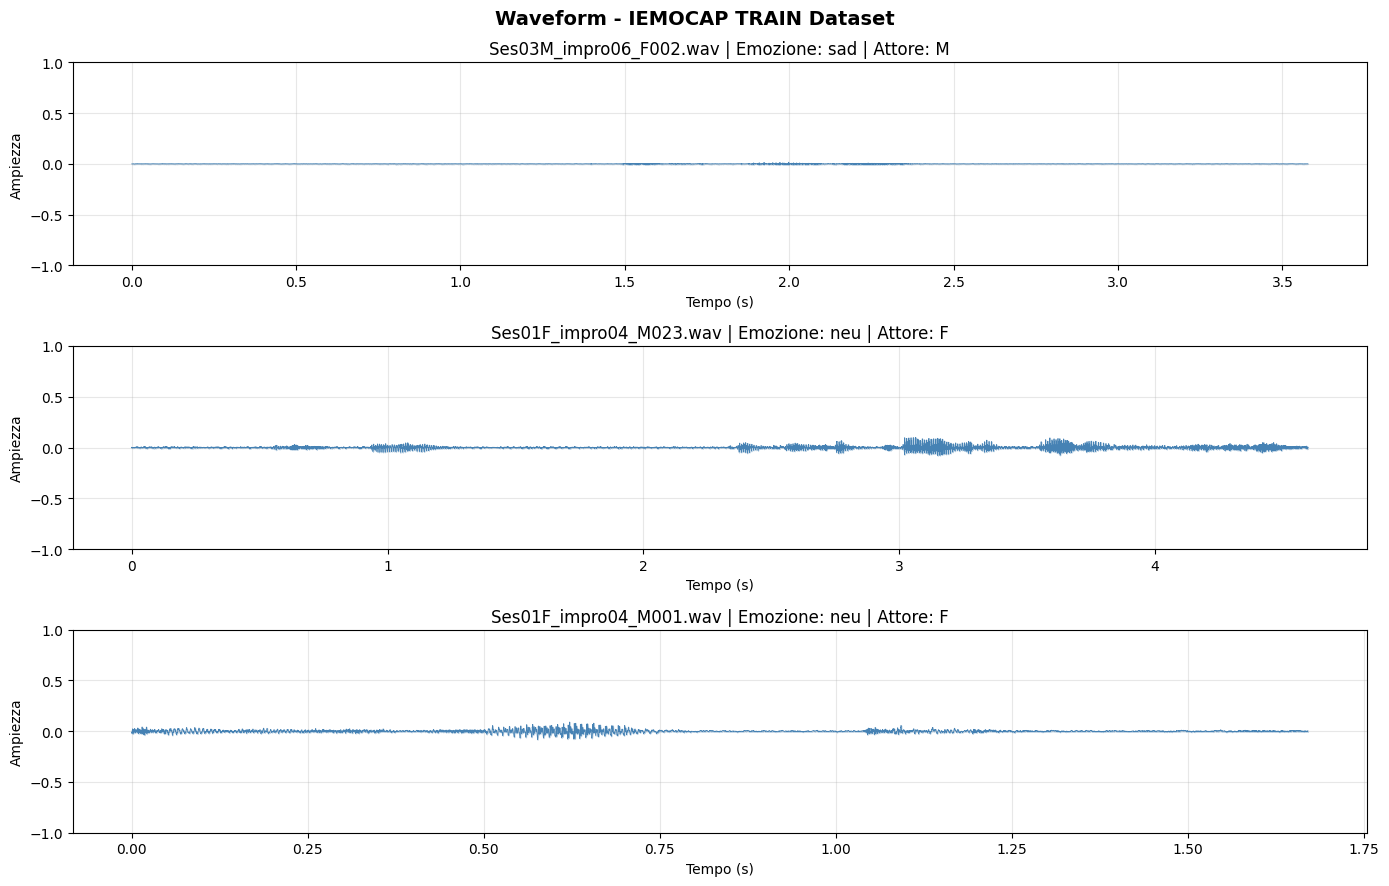

In [17]:
# Visualizza waveform IEMOCAP
plot_waveform(iemocap_datasets['train'], split='train', num_samples=3)

## 5️⃣ Visualizzazione Spettrogrammi

Visualizza i mel-spettrogrammi (stessa elaborazione usata dai dataset)

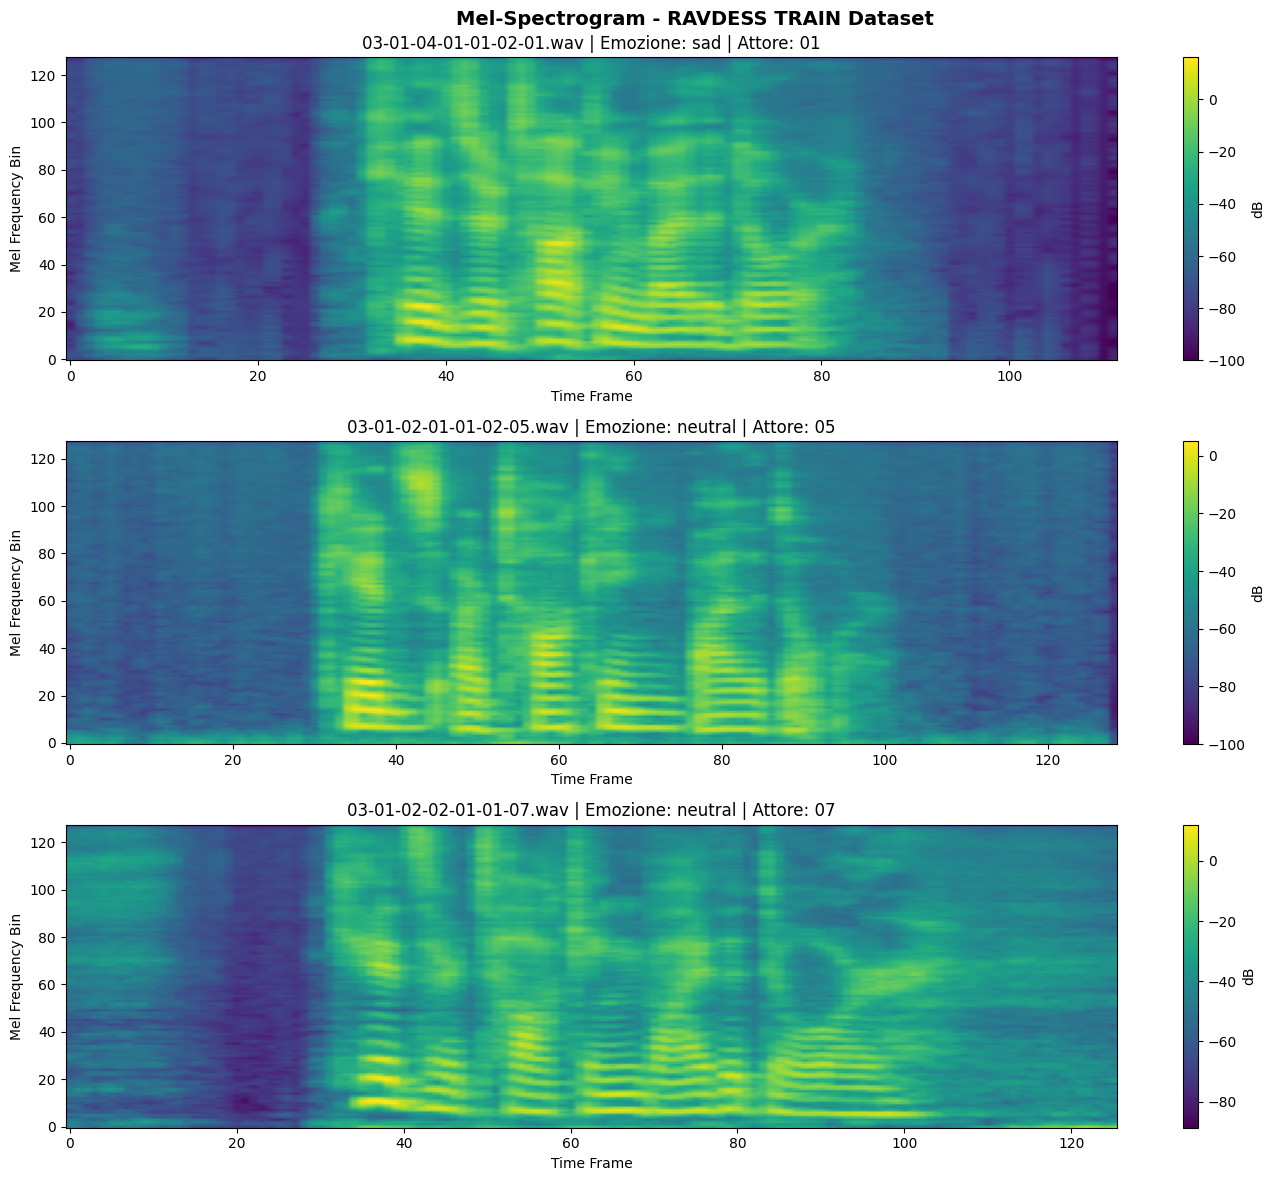

In [18]:
def plot_mel_spectrograms(dataset, split='train', num_samples=3):
    """
    Visualizza mel-spettrogrammi di campioni casuali
    """
    is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
    dataset_name = "RAVDESS" if is_ravdess else "IEMOCAP"
    data = dataset.samples
    
    # Parametri identici ai dataset
    sample_rate = 16000
    n_fft = 2048
    hop_length = 512
    n_mels = 128
    
    # Mel transform
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    db_transform = torchaudio.transforms.AmplitudeToDB()
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 4*num_samples))
    if num_samples == 1:
        axes = [axes]
    
    fig.suptitle(f"Mel-Spectrogram - {dataset_name} {split.upper()} Dataset", 
                 fontsize=14, fontweight='bold')
    
    for i in range(num_samples):
        idx = random.randint(0, len(data) - 1)
        sample = data[idx]
        
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
            actor = sample['metadata']['actor']
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
            actor = sample['actor']
        
        try:
            # Carica audio
            waveform_np, sr = librosa.load(str(audio_path), sr=sample_rate)
            waveform = torch.from_numpy(waveform_np).unsqueeze(0).float()
            
            # Calcola mel-spectrogram
            mel_spec = mel_transform(waveform)
            log_mel_spec = db_transform(mel_spec)
            
            # Visualizza
            ax = axes[i]
            im = ax.imshow(log_mel_spec[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
            ax.set_ylabel('Mel Frequency Bin')
            ax.set_xlabel('Time Frame')
            ax.set_title(f"{audio_path.name} | Emozione: {emotion} | Attore: {actor}")
            plt.colorbar(im, ax=ax, label='dB')
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Errore: {e}", ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

# Visualizza mel-spettrogrammi RAVDESS
plot_mel_spectrograms(ravdess_datasets['train'], split='train', num_samples=3)

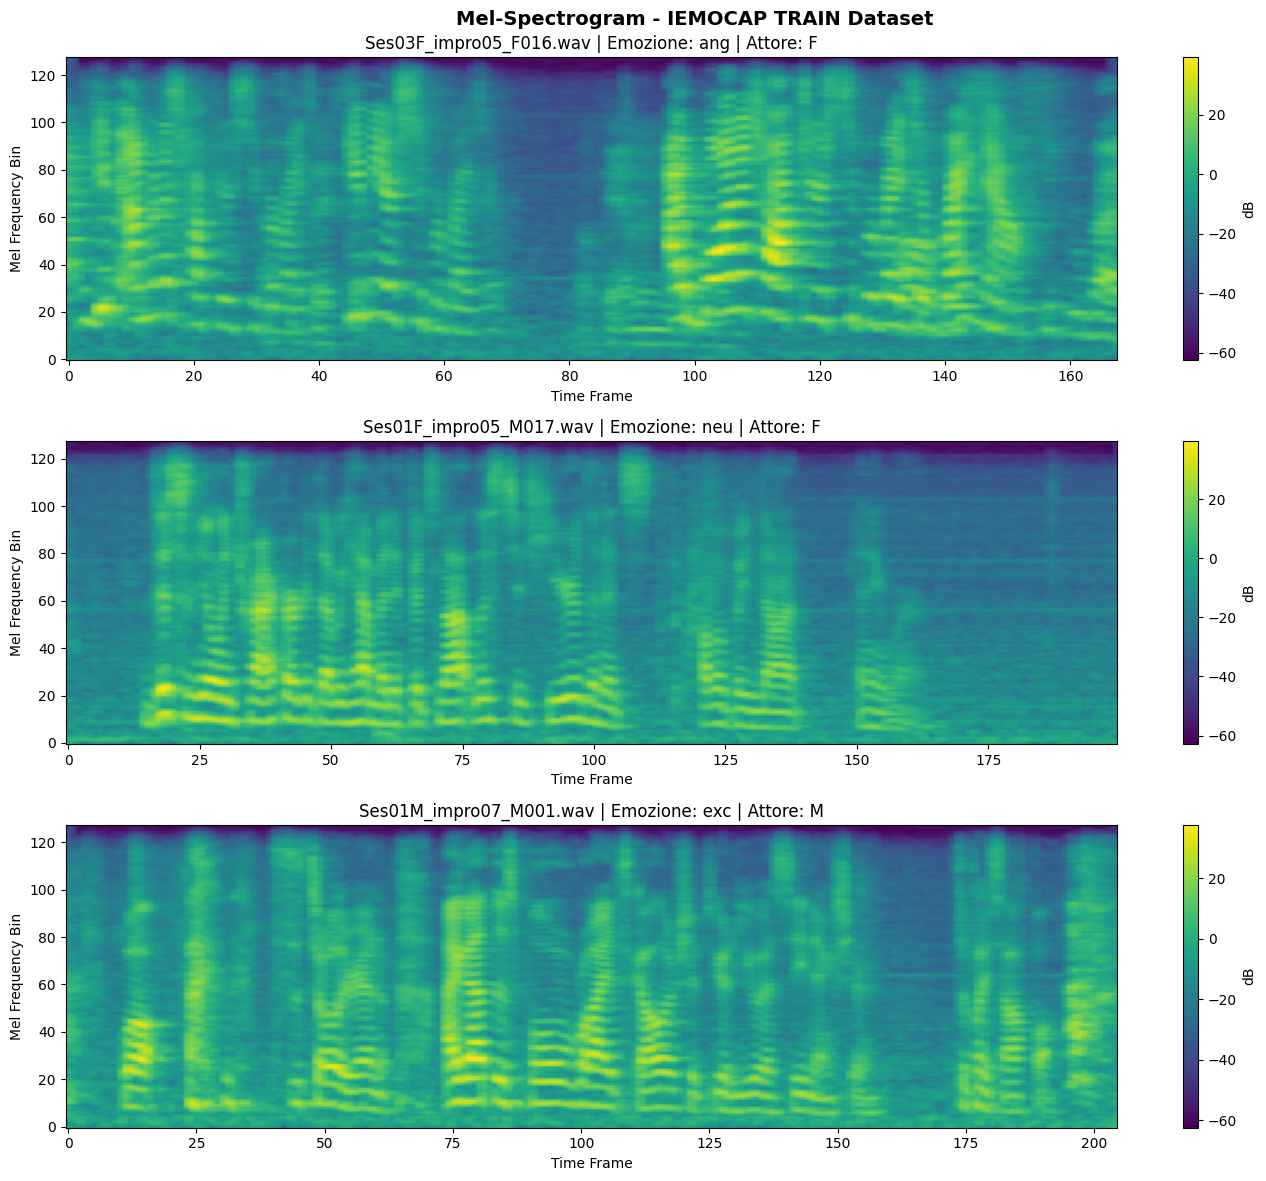

In [19]:
# Visualizza mel-spettrogrammi IEMOCAP
plot_mel_spectrograms(iemocap_datasets['train'], split='train', num_samples=3)

## 6️⃣ Ispezione Batch

Visualizza Multiple campioni in una griglia per valutazioni rapide

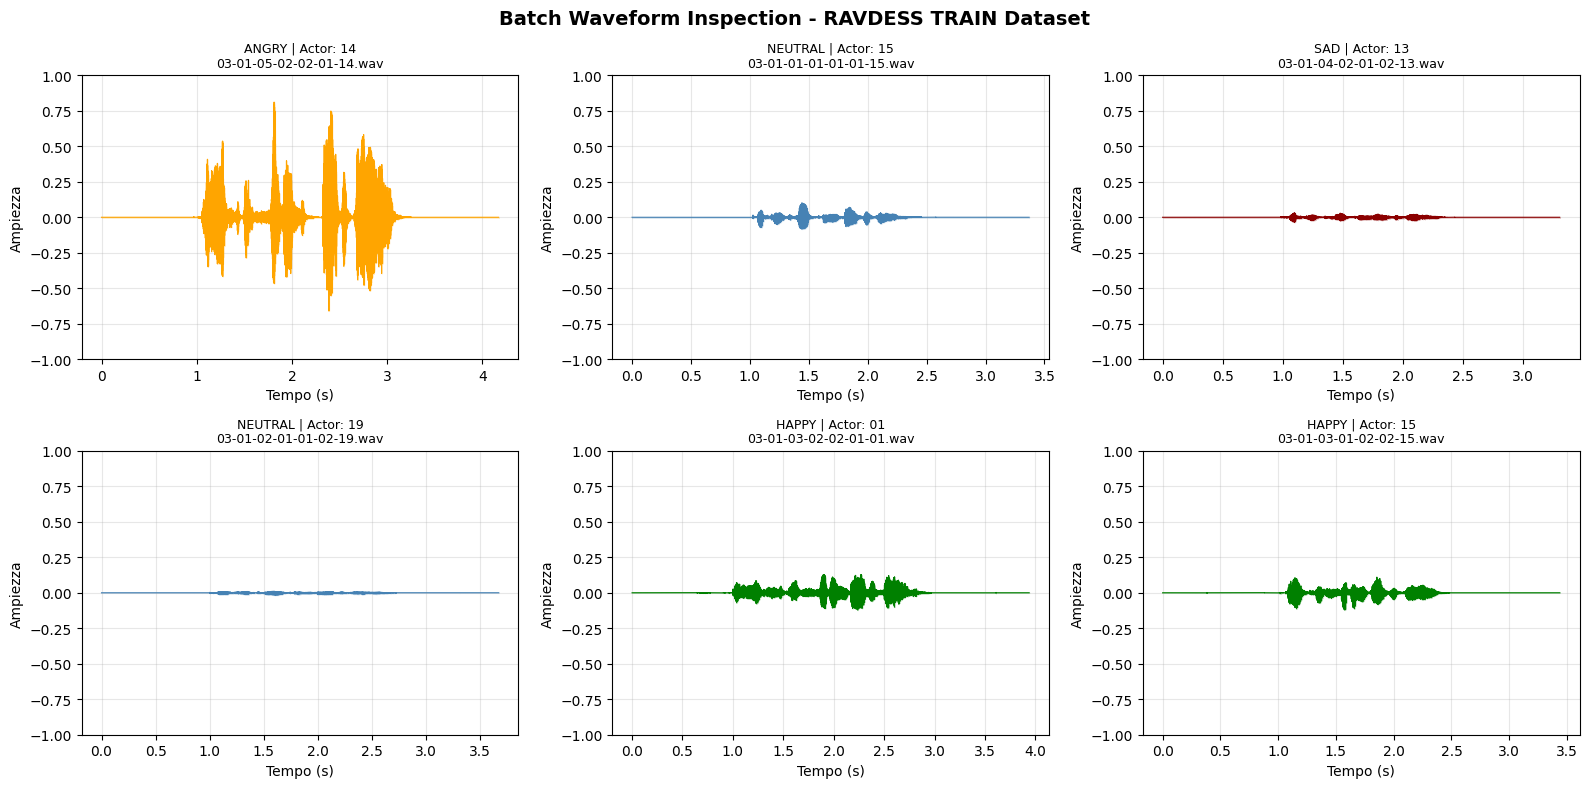

In [20]:
def batch_inspect_waveforms(dataset, split='train', num_samples=6):
    """
    Visualizza un batch di waveform in una griglia
    """
    is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
    dataset_name = "RAVDESS" if is_ravdess else "IEMOCAP"
    data = dataset.samples
    
    # Calcola dimensioni griglia
    cols = 3
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten()  # Appiattisci per accesso più semplice
    
    fig.suptitle(f"Batch Waveform Inspection - {dataset_name} {split.upper()} Dataset", 
                 fontsize=14, fontweight='bold')
    
    emotion_color_map = {
        'neutral': 'steelblue',
        'happy': 'green',
        'sad': 'darkred',
        'angry': 'orange'
    }
    
    for i in range(num_samples):
        idx = random.randint(0, len(data) - 1)
        sample = data[idx]
        
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
            actor = sample['metadata']['actor']
            title_extra = f"Actor: {actor}"
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
            actor = sample['actor']
            title_extra = f"Actor: {actor}"
        
        ax = axes[i]
        
        try:
            waveform, sr = librosa.load(str(audio_path), sr=None)
            time_axis = np.linspace(0, len(waveform) / sr, num=len(waveform))
            
            color = emotion_color_map.get(emotion, 'gray')
            ax.plot(time_axis, waveform, linewidth=0.8, color=color)
            ax.fill_between(time_axis, waveform, alpha=0.2, color=color)
            ax.set_ylabel('Ampiezza')
            ax.set_xlabel('Tempo (s)')
            ax.set_title(f"{emotion.upper()} | {title_extra}\n{audio_path.name}", fontsize=9)
            ax.set_ylim([-1.0, 1.0])
            ax.grid(True, alpha=0.3)
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Errore:\n{str(e)[:30]}", ha='center', va='center', 
                   fontsize=8, transform=ax.transAxes)
            ax.set_title(f"ERRORE | {audio_path.name}", fontsize=9, color='red')
    
    # Nascondi assi non usati
    for j in range(num_samples, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Ispezione batch RAVDESS
batch_inspect_waveforms(ravdess_datasets['train'], split='train', num_samples=6)

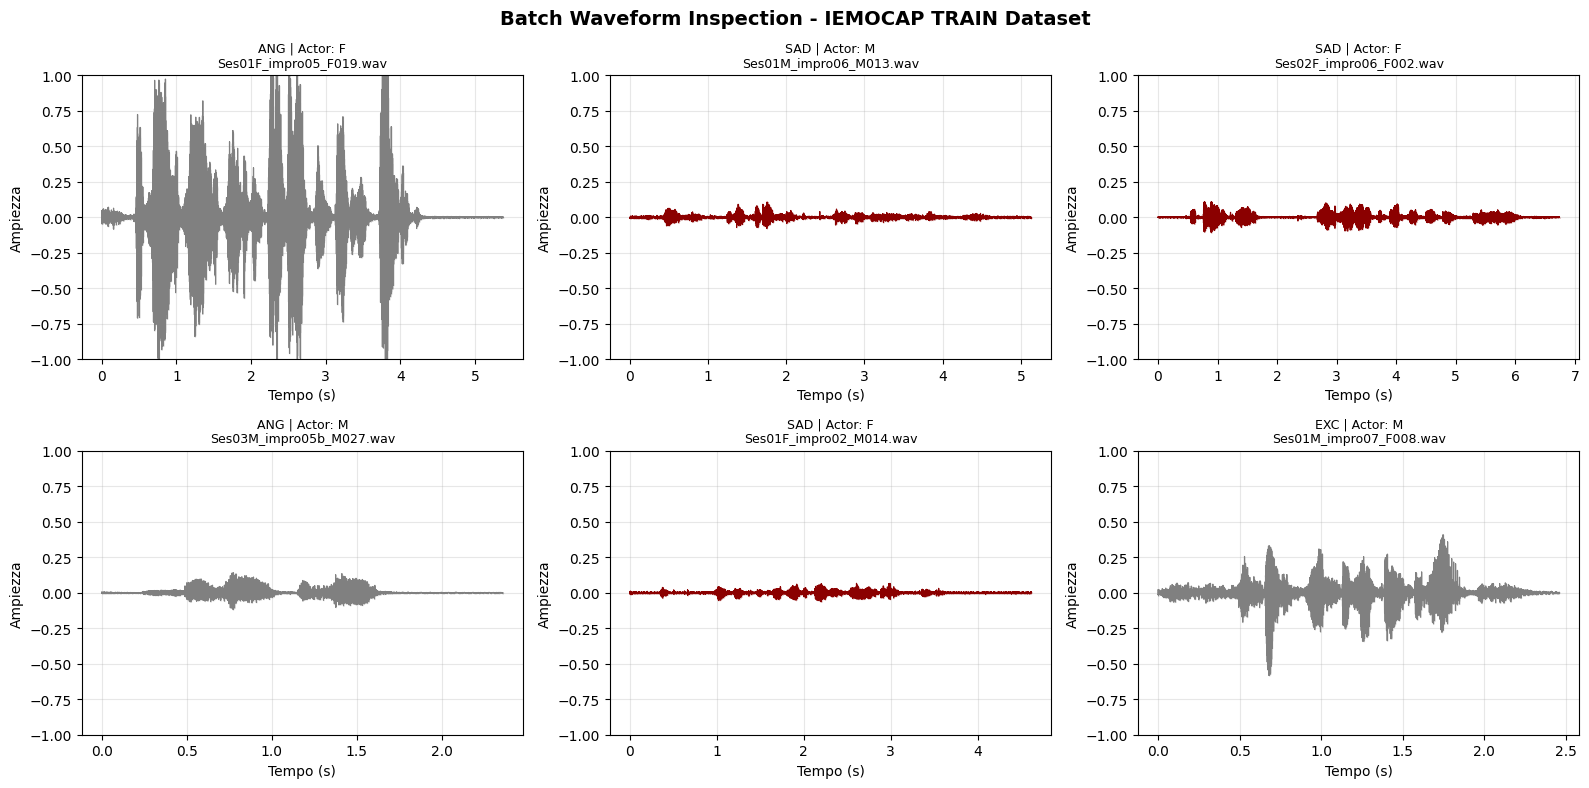

In [21]:
# Ispezione batch IEMOCAP
batch_inspect_waveforms(iemocap_datasets['train'], split='train', num_samples=6)

## 7️⃣ Valutazione Qualità Audio

Controlla l'integrità degli audio: durata, silenzio, clipping, e ampiezza

In [28]:
def check_audio_quality(dataset, split='train', sample_limit=None):
    """
    Analizza la qualità di tutti gli audio in un dataset
    """
    is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
    dataset_name = "RAVDESS" if is_ravdess else "IEMOCAP"
    data = dataset.samples
    
    if sample_limit is None:
        sample_limit = len(data)
    else:
        sample_limit = min(sample_limit, len(data))
    
    print(f"\n{'='*70}")
    print(f"📋 QUALITY ASSESSMENT - {dataset_name} {split.upper()}")
    print(f"{'='*70}")
    print(f"Analizzando {sample_limit}/{len(data)} campioni...\n")
    
    # Metriche
    quality_issues = {
        'too_quiet': [],      # Max ampiezza < 0.1
        'clipping': [],       # Max ampiezza >= 0.95
        'mostly_silent': [],  # >50% del segnale è silenzio
        'too_short': [],      # < 1 secondo
        'too_long': [],       # > 10 secondi
        'corrupted': []       # Non caricabile
    }
    
    durations = []
    amplitudes = []
    
    for idx in range(sample_limit):
        sample = data[idx]
        
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
        
        try:
            waveform, sr = librosa.load(str(audio_path), sr=None)
            duration = len(waveform) / sr
            max_amp = np.max(np.abs(waveform))
            
            durations.append(duration)
            amplitudes.append(max_amp)
            
            # Controllo 1: Audio troppo quieto
            if max_amp < 0.1:
                quality_issues['too_quiet'].append({
                    'file': audio_path.name,
                    'emotion': emotion,
                    'amplitude': max_amp
                })
            
            # Controllo 2: Clipping
            if max_amp >= 0.95:
                quality_issues['clipping'].append({
                    'file': audio_path.name,
                    'emotion': emotion,
                    'amplitude': max_amp
                })
            
            # Controllo 3: Principalmente silenzio
            threshold = np.max(np.abs(waveform)) * 0.1
            silent_frames = np.sum(np.abs(waveform) < threshold)
            silent_ratio = silent_frames / len(waveform)
            if silent_ratio > 0.8:
                quality_issues['mostly_silent'].append({
                    'file': audio_path.name,
                    'emotion': emotion,
                    'silent_ratio': silent_ratio
                })
            
            # Controllo 4: Durata
            if duration < 1.0:
                quality_issues['too_short'].append({
                    'file': audio_path.name,
                    'emotion': emotion,
                    'duration': duration
                })
            
            if duration > 10.0:
                quality_issues['too_long'].append({
                    'file': audio_path.name,
                    'emotion': emotion,
                    'duration': duration
                })
            
        except Exception as e:
            quality_issues['corrupted'].append({
                'file': audio_path.name,
                'error': str(e)[:50]
            })
    
    # Report stampa
    print(f"✅ Analisi completata su {sample_limit} campioni\n")
    
    print(f"📊 STATISTICHE DURATA:")
    print(f"   Min: {np.min(durations):.2f}s | Max: {np.max(durations):.2f}s | Mean: {np.mean(durations):.2f}s\n")
    
    print(f"📊 STATISTICHE AMPIEZZA:")
    print(f"   Min: {np.min(amplitudes):.4f} | Max: {np.max(amplitudes):.4f} | Mean: {np.mean(amplitudes):.4f}\n")
    
    print(f"⚠️  PROBLEMI RILEVATI:\n")
    
    total_issues = 0
    for issue_type, issues in quality_issues.items():
        if issues:
            print(f"   🔴 {issue_type.upper().replace('_', ' ')}: {len(issues)} file")
            for issue in issues[:3]:  # Mostra primi 3
                if 'amplitude' in issue:
                    print(f"      • {issue['file']} ({issue['emotion']}) - Amp: {issue['amplitude']:.4f}")
                elif 'silent_ratio' in issue:
                    print(f"      • {issue['file']} ({issue['emotion']}) - Silent: {issue['silent_ratio']:.1%}")
                elif 'duration' in issue:
                    print(f"      • {issue['file']} ({issue['emotion']}) - Duration: {issue['duration']:.2f}s")
                elif 'error' in issue:
                    print(f"      • {issue['file']} - Error: {issue['error']}")
            
            if len(issues) > 3:
                print(f"      ... e altri {len(issues) - 3}")
            
            total_issues += len(issues)
            print()
    
    if total_issues == 0:
        print("   ✅ Nessun problema rilevato!")
    else:
        print(f"   📌 Totale problemi: {total_issues}")

# Analizza qualità RAVDESS
check_audio_quality(ravdess_datasets['train'], split='train', sample_limit=1440)


📋 QUALITY ASSESSMENT - RAVDESS TRAIN
Analizzando 1440/1440 campioni...

✅ Analisi completata su 1440 campioni

📊 STATISTICHE DURATA:
   Min: 2.94s | Max: 4.80s | Mean: 3.70s

📊 STATISTICHE AMPIEZZA:
   Min: 0.0061 | Max: 0.9991 | Mean: 0.1823

⚠️  PROBLEMI RILEVATI:

   🔴 TOO QUIET: 828 file
      • 03-01-01-01-01-01-01.wav (neutral) - Amp: 0.0406
      • 03-01-01-01-01-02-01.wav (neutral) - Amp: 0.0482
      • 03-01-01-01-02-01-01.wav (neutral) - Amp: 0.0585
      ... e altri 825

   🔴 CLIPPING: 56 file
      • 03-01-05-02-02-02-01.wav (angry) - Amp: 0.9988
      • 03-01-05-02-02-01-02.wav (angry) - Amp: 0.9988
      • 03-01-05-02-01-01-03.wav (angry) - Amp: 0.9639
      ... e altri 53

   🔴 MOSTLY SILENT: 1440 file
      • 03-01-01-01-01-01-01.wav (neutral) - Silent: 85.9%
      • 03-01-01-01-01-02-01.wav (neutral) - Silent: 87.3%
      • 03-01-01-01-02-01-01.wav (neutral) - Silent: 87.1%
      ... e altri 1437

   📌 Totale problemi: 2324


In [31]:
# Analizza qualità IEMOCAP
check_audio_quality(iemocap_datasets['train'], split='train', sample_limit=1678)


📋 QUALITY ASSESSMENT - IEMOCAP TRAIN
Analizzando 1678/1678 campioni...

✅ Analisi completata su 1678 campioni

📊 STATISTICHE DURATA:
   Min: 0.58s | Max: 29.13s | Mean: 4.31s

📊 STATISTICHE AMPIEZZA:
   Min: 0.0050 | Max: 1.0000 | Mean: 0.2399

⚠️  PROBLEMI RILEVATI:

   🔴 TOO QUIET: 637 file
      • Ses01F_impro01_F000.wav (neu) - Amp: 0.0932
      • Ses01F_impro02_F000.wav (sad) - Amp: 0.0915
      • Ses01F_impro02_F001.wav (sad) - Amp: 0.0409
      ... e altri 634

   🔴 CLIPPING: 87 file
      • Ses01F_impro01_F012.wav (ang) - Amp: 1.0000
      • Ses01F_impro01_M011.wav (ang) - Amp: 1.0000
      • Ses01F_impro01_M013.wav (ang) - Amp: 1.0000
      ... e altri 84

   🔴 MOSTLY SILENT: 1660 file
      • Ses01F_impro01_F000.wav (neu) - Silent: 87.1%
      • Ses01F_impro01_F001.wav (neu) - Silent: 91.5%
      • Ses01F_impro01_F002.wav (neu) - Silent: 92.0%
      ... e altri 1657

   🔴 TOO SHORT: 9 file
      • Ses01F_impro03_F023.wav (neu) - Duration: 0.84s
      • Ses01M_impro07_F000.wa

## 📚 Funzioni Disponibili - Guida Rapida

Usa queste funzioni per testare gli audio:

### Playback Audio
```python
# Ascolta audio casuale RAVDESS
play_ravdess_sample(split='train', num_samples=3)

# Ascolta audio casuale IEMOCAP  
play_iemocap_sample(split='train', num_samples=3)
```

### Visualizzazioni
```python
# Waveform
plot_waveform(ravdess_datasets['train'], split='train', num_samples=3)
plot_waveform(iemocap_datasets['train'], split='train', num_samples=3)

# Mel-Spettrogrammi
plot_mel_spectrograms(ravdess_datasets['train'], split='train', num_samples=3)
plot_mel_spectrograms(iemocap_datasets['train'], split='train', num_samples=3)

# Batch Inspection
batch_inspect_waveforms(ravdess_datasets['train'], split='train', num_samples=6)
batch_inspect_waveforms(iemocap_datasets['train'], split='train', num_samples=6)
```

### Quality Assessment
```python
# Analizza qualità audio
check_audio_quality(ravdess_datasets['train'], split='train', sample_limit=100)
check_audio_quality(iemocap_datasets['train'], split='train', sample_limit=100)
```

### Split Disponibili
- **train**: Set di addestramento (maggiore numero di campioni)
- **validation**: Set di validazione (piccolo set)
- **test**: Set di test (piccolo set)

## 8️⃣ Sample come DataLoader - Verifica Correttezza Label

Visualizza 10 campioni come escono dal DataLoader (feature + label verificate)

In [24]:
from torch.utils.data import DataLoader

# Crea DataLoader per RAVDESS train (come usato nel training)
ravdess_loader = DataLoader(
    ravdess_datasets['train'],
    batch_size=1,
    shuffle=False,
    num_workers=0
)

# Crea DataLoader per IEMOCAP train
iemocap_loader = DataLoader(
    iemocap_datasets['train'],
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("=" * 80)
print("🎵 VISUALIZZAZIONE 10 SAMPLE RAVDESS TRAIN (come escono dal DataLoader)")
print("=" * 80)

# Visualizza 10 sample RAVDESS
for j, batch in enumerate(ravdess_loader):
    if j >= 10:
        break
    
    audio_features = batch['audio_features']  # [1, 1, 128, T]
    emotion_id = batch['emotion_id'].item()
    emotion_label = batch['emotion']
    actor_id = batch['actor_id']
    
    # Mappa emotion_id a label
    emotion_map = {0: 'neutral', 1: 'happy', 2: 'sad', 3: 'angry'}
    emotion_str = emotion_map.get(emotion_id, f"Unknown({emotion_id})")
    
    print(f"\n📂 Sample {j+1}/10")
    print(f"   Emotion ID: {emotion_id} -> Label: {emotion_str} | Attore: {actor_id[0]}")
    print(f"   Audio Features Shape: {audio_features.shape} (batch, channels, n_mels=128, time_frames)")
    print(f"   Spectrogram - Min: {audio_features.min():.2f} | Max: {audio_features.max():.2f} | Mean: {audio_features.mean():.2f} dB")
    
    # Verifica correttezza: estrai indice dal dataset per recuperare waveform originale
    sample_ravdess = ravdess_datasets['train'].samples[j]
    audio_path = sample_ravdess['path']
    metadata_emotion = sample_ravdess['metadata']['emotion_label']
    
    print(f"   ✓ Label Verification: File emotion={metadata_emotion}, ID emotion={emotion_str}, Match={metadata_emotion == emotion_str}")

print("\n" + "=" * 80)
print("🎙️  VISUALIZZAZIONE 10 SAMPLE IEMOCAP TRAIN (come escono dal DataLoader)")
print("=" * 80)

# Visualizza 10 sample IEMOCAP
for j, batch in enumerate(iemocap_loader):
    if j >= 10:
        break
    
    audio_features = batch['audio_features']  # [1, 1, 128, T]
    emotion_id = batch['emotion_id'].item()
    emotion_label = batch['emotion']
    actor_id = batch['actor_id']
    
    emotion_map = {0: 'neutral', 1: 'happy', 2: 'sad', 3: 'angry'}
    emotion_str = emotion_map.get(emotion_id, f"Unknown({emotion_id})")
    
    print(f"\n📂 Sample {j+1}/10")
    print(f"   Emotion ID: {emotion_id} -> Label: {emotion_str} | Attore: {actor_id[0]}")
    print(f"   Audio Features Shape: {audio_features.shape} (batch, channels, n_mels=128, time_frames)")
    print(f"   Spectrogram - Min: {audio_features.min():.2f} | Max: {audio_features.max():.2f} | Mean: {audio_features.mean():.2f} dB")
    
    # Verifica correttezza
    sample_iemocap = iemocap_datasets['train'].samples[j]
    audio_path = sample_iemocap['audio_path']
    metadata_emotion = sample_iemocap['label']
    
    print(f"   ✓ Label Verification: File emotion={metadata_emotion}, ID emotion={emotion_str}, Match={metadata_emotion == emotion_str}")

🎵 VISUALIZZAZIONE 10 SAMPLE RAVDESS TRAIN (come escono dal DataLoader)

📂 Sample 1/10
   Emotion ID: 0 -> Label: neutral | Attore: 01
   Audio Features Shape: torch.Size([1, 1, 128, 94]) (batch, channels, n_mels=128, time_frames)
   Spectrogram - Min: -3.75 | Max: 4.77 | Mean: -0.00 dB
   ✓ Label Verification: File emotion=neutral, ID emotion=neutral, Match=True

📂 Sample 2/10
   Emotion ID: 0 -> Label: neutral | Attore: 01
   Audio Features Shape: torch.Size([1, 1, 128, 94]) (batch, channels, n_mels=128, time_frames)
   Spectrogram - Min: -3.29 | Max: 4.43 | Mean: -0.00 dB
   ✓ Label Verification: File emotion=neutral, ID emotion=neutral, Match=True

📂 Sample 3/10
   Emotion ID: 0 -> Label: neutral | Attore: 01
   Audio Features Shape: torch.Size([1, 1, 128, 94]) (batch, channels, n_mels=128, time_frames)
   Spectrogram - Min: -1.74 | Max: 2.43 | Mean: -0.00 dB
   ✓ Label Verification: File emotion=neutral, ID emotion=neutral, Match=True

📂 Sample 4/10
   Emotion ID: 0 -> Label: neutr


📊 WAVEFORM VISUALIZATION WITH LABELS


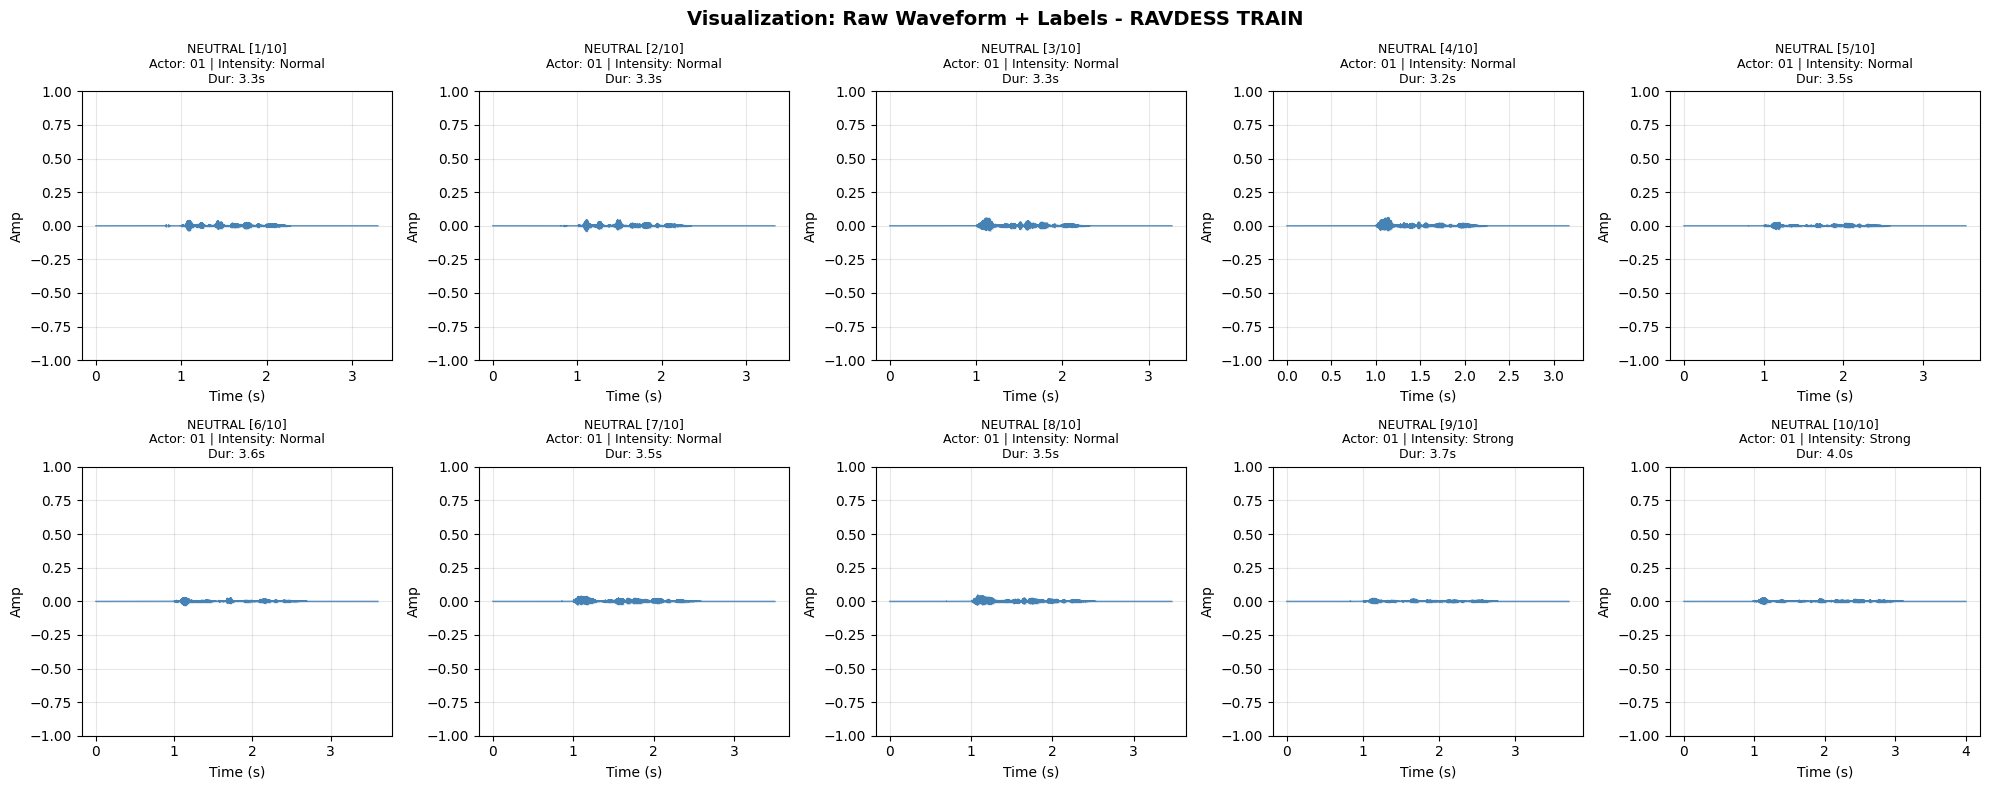

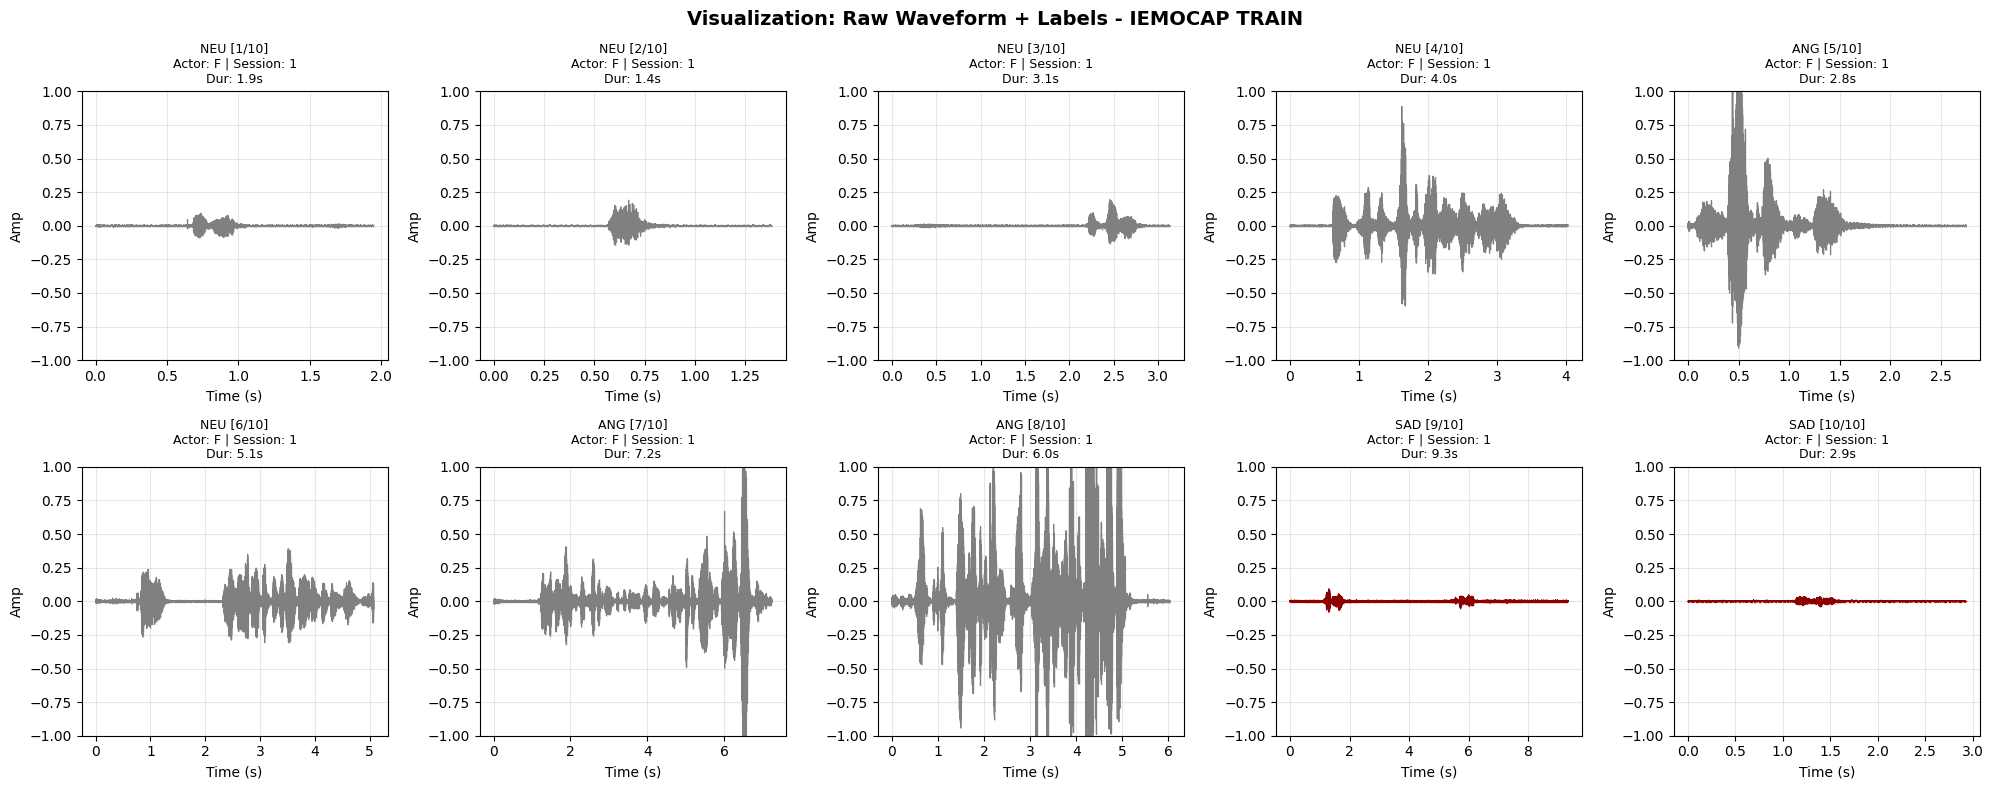

In [25]:
def visualize_audio_with_labels(dataset, dataset_name, num_samples=10):
    """
    Visualizza waveform con etichette per verificare correttezza labels
    """
    cols = 5
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    fig.suptitle(f"Visualization: Raw Waveform + Labels - {dataset_name} TRAIN", 
                 fontsize=14, fontweight='bold')
    
    emotion_color_map = {
        'neutral': 'steelblue',
        'happy': 'green',
        'sad': 'darkred',
        'angry': 'orange'
    }
    
    for i in range(min(num_samples, len(dataset.samples))):
        sample = dataset.samples[i]
        ax = axes[i]
        
        is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
        
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
            intensity = sample['metadata']['intensity']
            actor = sample['metadata']['actor']
            title_info = f"Actor: {actor} | Intensity: {'Normal' if intensity == '01' else 'Strong'}"
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
            actor = sample['actor']
            session = sample['session_id']
            title_info = f"Actor: {actor} | Session: {session}"
        
        try:
            waveform, sr = librosa.load(str(audio_path), sr=None)
            time_axis = np.linspace(0, len(waveform) / sr, num=len(waveform))
            duration = len(waveform) / sr
            
            color = emotion_color_map.get(emotion, 'gray')
            ax.plot(time_axis, waveform, linewidth=0.8, color=color)
            ax.fill_between(time_axis, waveform, alpha=0.2, color=color)
            ax.set_ylabel('Amp')
            ax.set_xlabel('Time (s)')
            ax.set_title(f"{emotion.upper()} [{i+1}/10]\n{title_info}\nDur: {duration:.1f}s", fontsize=9)
            ax.set_ylim([-1.0, 1.0])
            ax.grid(True, alpha=0.3)
            
        except Exception as e:
            ax.text(0.5, 0.5, f"ERROR:\n{str(e)[:30]}", ha='center', va='center', 
                   fontsize=8, transform=ax.transAxes, color='red')
    
    # Nascondi assi non usati
    for j in range(num_samples, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("📊 WAVEFORM VISUALIZATION WITH LABELS")
print("=" * 80)

visualize_audio_with_labels(ravdess_datasets['train'], "RAVDESS", num_samples=10)
visualize_audio_with_labels(iemocap_datasets['train'], "IEMOCAP", num_samples=10)

## 9️⃣ Statistiche Dettagliate Dataset

Analisi approfondita: genere, emozioni, durata, silenzi, strategie di taglio audio

In [26]:
def detailed_statistics(dataset, dataset_name, max_samples=None):
    """
    Analizza statistiche dettagliate: genere, emozioni, durata, silenzi, etc.
    """
    data = dataset.samples
    is_ravdess = isinstance(dataset, CustomRAVDESSDataset)
    
    if max_samples is None:
        max_samples = len(data)
    else:
        max_samples = min(max_samples, len(data))
    
    print(f"\n{'='*90}")
    print(f"📊 DETAILED STATISTICS - {dataset_name} TRAIN SET")
    print(f"{'='*90}\n")
    print(f"Analyzing {max_samples}/{len(data)} samples...\n")
    
    # Statistiche per genere
    gender_counts = defaultdict(int)
    gender_emotion_counts = defaultdict(lambda: defaultdict(int))
    
    # Statistiche per emozione
    emotion_stats = defaultdict(lambda: {
        'count': 0,
        'durations': [],
        'amplitudes': [],
        'silent_ratios': []
    })
    
    durations_all = []
    amplitudes_all = []
    silent_ratios_all = []
    
    print("🔄 Processing audio files...\n")
    
    for idx in range(max_samples):
        sample = data[idx]
        
        if is_ravdess:
            audio_path = sample['path']
            emotion = sample['metadata']['emotion_label']
            actor = sample['metadata']['actor']  # 'M' o 'F'
        else:
            audio_path = sample['audio_path']
            emotion = sample['label']
            # Per IEMOCAP: estrai genere dalla sessione (e.g., 'Ses04F_impro01' -> F per femmina)
            sample_id = sample['sample_id']
            actor = 'F' if 'F' in sample_id else 'M'
        
        try:
            waveform, sr = librosa.load(str(audio_path), sr=None)
            duration = len(waveform) / sr
            max_amp = np.max(np.abs(waveform))
            
            # Calcola silent ratio (percentuale di segnale sotto il 10% del max)
            threshold = max_amp * 0.1
            silent_frames = np.sum(np.abs(waveform) < threshold)
            silent_ratio = silent_frames / len(waveform)
            
            # Colleziona statistiche globali
            durations_all.append(duration)
            amplitudes_all.append(max_amp)
            silent_ratios_all.append(silent_ratio)
            
            # Colleziona per genere
            gender_counts[actor] += 1
            gender_emotion_counts[actor][emotion] += 1
            
            # Colleziona per emozione
            emotion_stats[emotion]['count'] += 1
            emotion_stats[emotion]['durations'].append(duration)
            emotion_stats[emotion]['amplitudes'].append(max_amp)
            emotion_stats[emotion]['silent_ratios'].append(silent_ratio)
            
        except Exception as e:
            print(f"⚠️  Error processing {audio_path.name}: {e}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STAMPA STATISTICHE PER GENERE
    # ═══════════════════════════════════════════════════════════════════════
    print(f"\n{'─'*90}")
    print(f"📢 STATISTICS BY GENDER")
    print(f"{'─'*90}\n")
    
    for gender in ['M', 'F']:
        count = gender_counts[gender]
        gender_name = "MALE" if gender == 'M' else "FEMALE"
        print(f"  {gender_name}: {count} samples ({count/max_samples*100:.1f}%)")
        
        emotion_counts = gender_emotion_counts[gender]
        for emotion in ['neutral', 'happy', 'sad', 'angry']:
            e_count = emotion_counts[emotion]
            bar = "▓" * (e_count // 2)
            print(f"      {emotion:10s}: {e_count:3d} {bar}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STAMPA STATISTICHE PER EMOZIONE
    # ═══════════════════════════════════════════════════════════════════════
    print(f"\n{'─'*90}")
    print(f"😊 STATISTICS BY EMOTION")
    print(f"{'─'*90}\n")
    
    emotion_order = ['neutral', 'happy', 'sad', 'angry']
    for emotion in emotion_order:
        stats = emotion_stats[emotion]
        if stats['count'] == 0:
            continue
        
        durations = np.array(stats['durations'])
        amplitudes = np.array(stats['amplitudes'])
        silent_ratios = np.array(stats['silent_ratios'])
        
        print(f"  {emotion.upper()}: {stats['count']} samples")
        print(f"      Duration:    min={durations.min():.2f}s | max={durations.max():.2f}s | mean={durations.mean():.2f}s | std={durations.std():.2f}s")
        print(f"      Amplitude:   min={amplitudes.min():.4f} | max={amplitudes.max():.4f} | mean={amplitudes.mean():.4f}")
        print(f"      Silent Ratio: min={silent_ratios.min():.1%} | max={silent_ratios.max():.1%} | mean={silent_ratios.mean():.1%}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STATISTICHE GLOBALI
    # ═══════════════════════════════════════════════════════════════════════
    print(f"\n{'─'*90}")
    print(f"🎯 GLOBAL STATISTICS (All {max_samples} samples)")
    print(f"{'─'*90}\n")
    
    durations_arr = np.array(durations_all)
    amplitudes_arr = np.array(amplitudes_all)
    silent_ratios_arr = np.array(silent_ratios_all)
    
    print(f"  DURATION:")
    print(f"      Min: {durations_arr.min():.2f}s | Max: {durations_arr.max():.2f}s")
    print(f"      Mean: {durations_arr.mean():.2f}s | Std: {durations_arr.std():.2f}s")
    print(f"      Percentiles: 25%={np.percentile(durations_arr, 25):.2f}s | 50%={np.percentile(durations_arr, 50):.2f}s | 75%={np.percentile(durations_arr, 75):.2f}s")
    
    print(f"\n  AMPLITUDE (Loudness):")
    print(f"      Min: {amplitudes_arr.min():.4f} | Max: {amplitudes_arr.max():.4f}")
    print(f"      Mean: {amplitudes_arr.mean():.4f} | Std: {amplitudes_arr.std():.4f}")
    print(f"      Median: {np.median(amplitudes_arr):.4f}")
    
    print(f"\n  SILENCE RATIO (fraction of signal < 10% max amplitude):")
    print(f"      Min: {silent_ratios_arr.min():.1%} | Max: {silent_ratios_arr.max():.1%}")
    print(f"      Mean: {silent_ratios_arr.mean():.1%} | Std: {silent_ratios_arr.std():.1%}")
    print(f"      Median: {np.median(silent_ratios_arr):.1%}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # RACCOMANDAZIONI PER AUDIO PROCESSING
    # ═══════════════════════════════════════════════════════════════════════
    print(f"\n{'─'*90}")
    print(f"💡 RECOMMENDATIONS FOR AUDIO PROCESSING")
    print(f"{'─'*90}\n")
    
    target_duration = 3.0  # Durata target del modello
    
    print(f"  1. CLIP LENGTH:")
    print(f"     • Current target: {target_duration:.1f}s")
    print(f"     • Min audio: {durations_arr.min():.2f}s (requires PADDING)")
    print(f"     • Max audio: {durations_arr.max():.2f}s (requires CENTER CROP)")
    print(f"     • Median audio: {np.median(durations_arr):.2f}s")
    
    short_percentage = (durations_arr < target_duration).sum() / len(durations_arr) * 100
    long_percentage = (durations_arr > target_duration).sum() / len(durations_arr) * 100
    
    print(f"     • {short_percentage:.1f}% of audios are SHORTER than {target_duration}s (need padding)")
    print(f"     • {long_percentage:.1f}% of audios are LONGER than {target_duration}s (need center crop)")
    
    print(f"\n  2. AMPLITUDE NORMALIZATION:")
    quiet_count = (amplitudes_arr < 0.1).sum()
    loud_count = (amplitudes_arr > 0.9).sum()
    
    print(f"     • Very quiet samples (amp < 0.1): {quiet_count} ({quiet_count/len(amplitudes_arr)*100:.1f}%)")
    print(f"     • Very loud samples (amp > 0.9): {loud_count} ({loud_count/len(amplitudes_arr)*100:.1f}%)")
    print(f"     • Recommended normalization: StandardScaler or per-sample normalization")
    
    print(f"\n  3. SILENCE TRIMMING:")
    high_silence = (silent_ratios_arr > 0.5).sum()
    print(f"     • Samples with >50% silence: {high_silence} ({high_silence/len(silent_ratios_arr)*100:.1f}%)")
    print(f"     • Average silence per sample: {silent_ratios_arr.mean():.1%}")
    print(f"     • Recommendation: Consider trimming leading/trailing silence before center crop")
    
    print(f"\n  4. MEL-SPECTROGRAM CONVERSION:")
    print(f"     • Sample rate: 16000 Hz")
    print(f"     • At 3.0s duration: {int(3.0 * 16000)} samples")
    print(f"     • With n_fft=2048, hop_length=512: ~94 time frames")
    print(f"     • Output shape per sample: (1, 128, ~94) for log-mel-spectrogram")
    
    return {
        'durations': durations_arr,
        'amplitudes': amplitudes_arr,
        'silent_ratios': silent_ratios_arr,
        'gender_counts': gender_counts,
        'emotion_stats': emotion_stats
    }

# Raccogli statistiche per RAVDESS train
print("\n" + "█"*90)
ravdess_stats = detailed_statistics(ravdess_datasets['train'], "RAVDESS")

# Raccogli statistiche per IEMOCAP train
print("\n" + "█"*90)
iemocap_stats = detailed_statistics(iemocap_datasets['train'], "IEMOCAP")


██████████████████████████████████████████████████████████████████████████████████████████

📊 DETAILED STATISTICS - RAVDESS TRAIN SET

Analyzing 1440/1440 samples...

🔄 Processing audio files...


──────────────────────────────────────────────────────────────────────────────────────────
📢 STATISTICS BY GENDER
──────────────────────────────────────────────────────────────────────────────────────────

  MALE: 0 samples (0.0%)
      neutral   :   0 
      happy     :   0 
      sad       :   0 
      angry     :   0 
  FEMALE: 0 samples (0.0%)
      neutral   :   0 
      happy     :   0 
      sad       :   0 
      angry     :   0 

──────────────────────────────────────────────────────────────────────────────────────────
😊 STATISTICS BY EMOTION
──────────────────────────────────────────────────────────────────────────────────────────

  NEUTRAL: 480 samples
      Duration:    min=2.94s | max=4.77s | mean=3.67s | std=0.33s
      Amplitude:   min=0.0067 | max=0.1292 | mean=0.0421
      

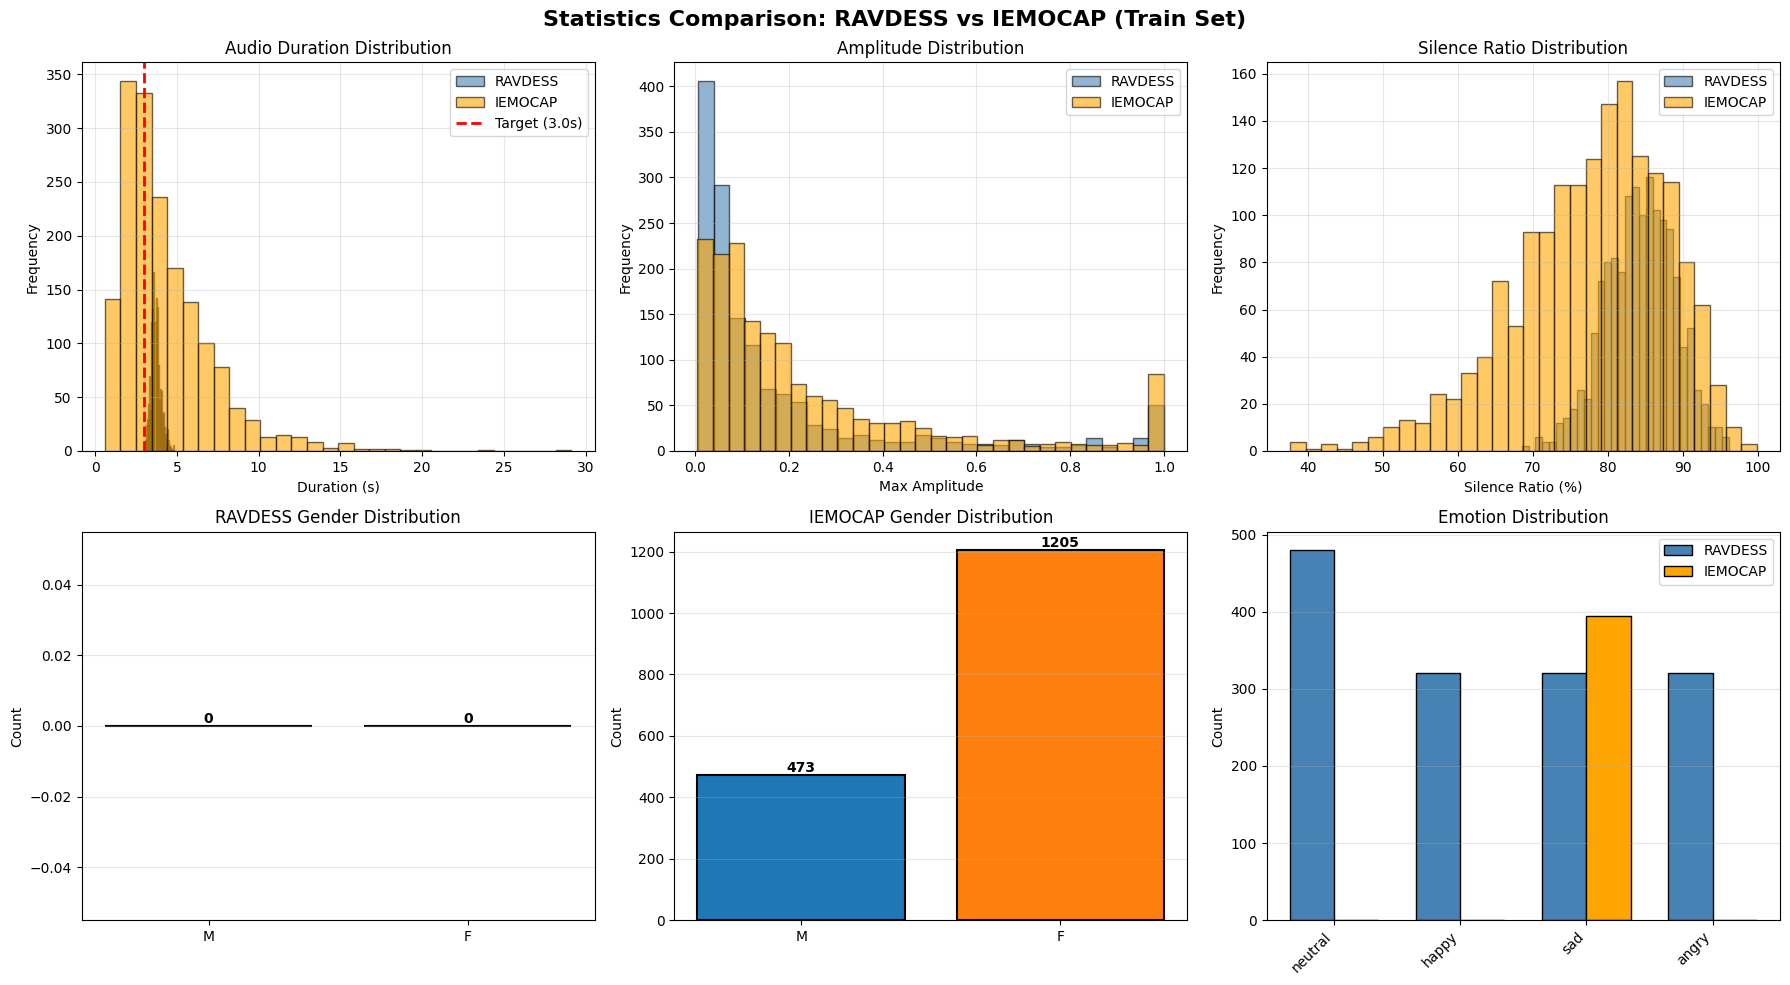

In [27]:
def plot_statistics_comparison(ravdess_stats, iemocap_stats):
    """
    Visualizza graficamente le statistiche a confronto tra i due dataset
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Statistics Comparison: RAVDESS vs IEMOCAP (Train Set)", fontsize=16, fontweight='bold')
    
    # 1. Duration Distribution
    ax = axes[0, 0]
    ax.hist(ravdess_stats['durations'], bins=30, alpha=0.6, label='RAVDESS', color='steelblue', edgecolor='black')
    ax.hist(iemocap_stats['durations'], bins=30, alpha=0.6, label='IEMOCAP', color='orange', edgecolor='black')
    ax.axvline(3.0, color='red', linestyle='--', linewidth=2, label='Target (3.0s)')
    ax.set_xlabel('Duration (s)')
    ax.set_ylabel('Frequency')
    ax.set_title('Audio Duration Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Amplitude Distribution
    ax = axes[0, 1]
    ax.hist(ravdess_stats['amplitudes'], bins=30, alpha=0.6, label='RAVDESS', color='steelblue', edgecolor='black')
    ax.hist(iemocap_stats['amplitudes'], bins=30, alpha=0.6, label='IEMOCAP', color='orange', edgecolor='black')
    ax.set_xlabel('Max Amplitude')
    ax.set_ylabel('Frequency')
    ax.set_title('Amplitude Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Silence Ratio Distribution
    ax = axes[0, 2]
    ax.hist(ravdess_stats['silent_ratios']*100, bins=30, alpha=0.6, label='RAVDESS', color='steelblue', edgecolor='black')
    ax.hist(iemocap_stats['silent_ratios']*100, bins=30, alpha=0.6, label='IEMOCAP', color='orange', edgecolor='black')
    ax.set_xlabel('Silence Ratio (%)')
    ax.set_ylabel('Frequency')
    ax.set_title('Silence Ratio Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Gender Distribution - RAVDESS
    ax = axes[1, 0]
    genders = ['M', 'F']
    counts_ravdess = [ravdess_stats['gender_counts'].get(g, 0) for g in genders]
    colors = ['#1f77b4', '#ff7f0e']
    bars = ax.bar(genders, counts_ravdess, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Count')
    ax.set_title('RAVDESS Gender Distribution')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. Gender Distribution - IEMOCAP
    ax = axes[1, 1]
    genders = ['M', 'F']
    counts_iemocap = [iemocap_stats['gender_counts'].get(g, 0) for g in genders]
    bars = ax.bar(genders, counts_iemocap, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Count')
    ax.set_title('IEMOCAP Gender Distribution')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. Emotion Distribution Comparison
    ax = axes[1, 2]
    emotions = ['neutral', 'happy', 'sad', 'angry']
    ravdess_counts = [ravdess_stats['emotion_stats'][e]['count'] for e in emotions]
    iemocap_counts = [iemocap_stats['emotion_stats'][e]['count'] for e in emotions]
    
    x = np.arange(len(emotions))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, ravdess_counts, width, label='RAVDESS', color='steelblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, iemocap_counts, width, label='IEMOCAP', color='orange', edgecolor='black')
    
    ax.set_ylabel('Count')
    ax.set_title('Emotion Distribution')
    ax.set_xticks(x)
    ax.set_xticklabels(emotions, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Visualizza confronto statistiche
plot_statistics_comparison(ravdess_stats, iemocap_stats)